# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [54]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

# 1.Replacing corpus with your own paragraph

In [55]:
corpus = '''
Celebal Technologies is a leading technology consulting and digital transformation company that empowers businesses with innovative solutions using cloud computing, artificial intelligence, machine learning, data engineering, analytics, and enterprise applications. The company is committed to helping organizations solve complex business challenges through modern technologies and data-driven decision making. At Celebal Technologies, innovation, collaboration, and continuous learning form the foundation of the workplace culture. Employees are encouraged to think creatively, explore new ideas, and work together to deliver impactful solutions for clients across various industries. The organization believes in creating an environment where individuals can grow professionally while contributing to meaningful projects that leverage the latest advancements in technology. Celebal Technologies partners with global enterprises to build scalable, secure, and intelligent applications that improve efficiency, productivity, and customer experience. The company invests heavily in research, employee development, technical certifications, hackathons, and knowledge-sharing sessions to ensure that its workforce remains up to date with emerging technologies such as generative AI, deep learning, natural language processing, computer vision, and big data analytics. Every project at Celebal Technologies focuses on delivering quality, innovation, and measurable business value while maintaining the highest standards of professionalism and customer satisfaction. The company's culture promotes trust, respect, accountability, teamwork, and continuous improvement, enabling employees to take ownership of their work and contribute confidently to challenging business problems. Through strong partnerships, technical excellence, and a passion for innovation, Celebal Technologies continues to transform businesses worldwide while creating opportunities for talented professionals to learn, innovate, and build solutions that shape the future of digital transformation.
'''
print(corpus)


Celebal Technologies is a leading technology consulting and digital transformation company that empowers businesses with innovative solutions using cloud computing, artificial intelligence, machine learning, data engineering, analytics, and enterprise applications. The company is committed to helping organizations solve complex business challenges through modern technologies and data-driven decision making. At Celebal Technologies, innovation, collaboration, and continuous learning form the foundation of the workplace culture. Employees are encouraged to think creatively, explore new ideas, and work together to deliver impactful solutions for clients across various industries. The organization believes in creating an environment where individuals can grow professionally while contributing to meaningful projects that leverage the latest advancements in technology. Celebal Technologies partners with global enterprises to build scalable, secure, and intelligent applications that improve 

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [56]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 171
X shape: (256, 256)
y shape: (256,)


#(2,3,4) For three models increased Embedding dimensions and epochs and changed hidden units from 64->128.

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [57]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [58]:
lstm_model = Sequential([
    Embedding(total_words,64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [59]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

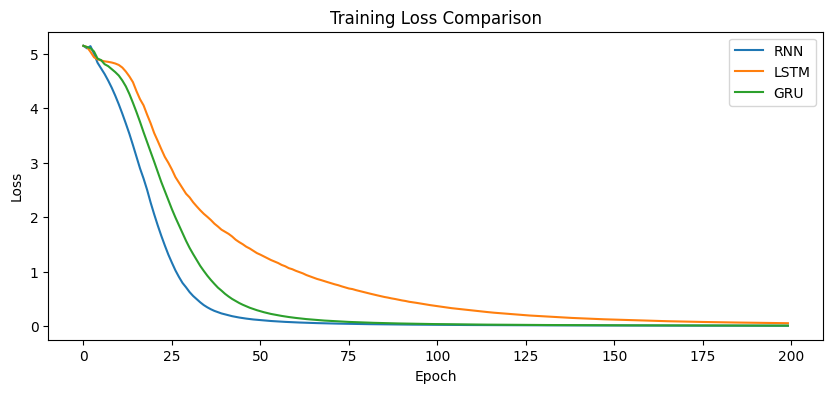

In [60]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [61]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [62]:
print("RNN :", generate_text(rnn_model, "Celebal", 10))
print("LSTM:", generate_text(lstm_model, "Celebal", 10))
print("GRU :", generate_text(gru_model, "Celebal", 10))

RNN : Celebal technologies is a leading technology consulting and digital transformation company
LSTM: Celebal technologies is a leading technology consulting and digital transformation company
GRU : Celebal technologies is a leading technology consulting and digital transformation company


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**